In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ccld/conference/Conference Post-Assessment Data.csv", encoding='latin1')

In [ ]:
df.head()

,Progress,Duration (in seconds),Finished,DistributionChannel,Which Session,Feedback_1,Feedback_2,Feedback_3,Feedback_4,Q28_1,...,Specific - Stand Out,Specific - Stand Out.1,Specific - Mess,Specific - Mess.1,Specific - Mess.2,Specific - Like_1,Specific - Like_2,Specific - Like_3,Specific - Like_4,Q47
0,Progress,Duration (in seconds),Finished,Distribution Channel,Which Session did you attend?,Please rate your level of agreement with the f...,Please rate your level of agreement with the f...,Please rate your level of agreement with the f...,Please rate your level of agreement with the f...,Please rate your level of agreement with the f...,...,Have you heard about internship and work-based...,What support is most important to you as you p...,Are you currently navigating a need that requi...,"When you think about advocating for yourself, ...",There are always many perspectives and/or expe...,Please indicate your level of agreement with t...,Please indicate your level of agreement with t...,Please indicate your level of agreement with t...,Please indicate your level of agreement with t...,What general feedback do you have for this ses...
1,100,15,TRUE,preview,"The Mess, the hassle, and the Importance of Se...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100,22,TRUE,preview,"Connecting Work, Learning, and Leadership: Lev...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100,2,TRUE,preview,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100,4103,TRUE,anonymous,Micro-Habits for Success: Thriving Inside and ...,Strongly Disagree,Disagree,Disagree,Strongly Disagree,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I felt like I can not take anything away from ...


In [ ]:
df.isnull().sum()


,0
Progress,0
Duration (in seconds),0
Finished,0
DistributionChannel,0
Which Session,2
Feedback_1,9
Feedback_2,9
Feedback_3,10
Feedback_4,10
Q28_1,40


In [ ]:
# prompt: make the row 0 column names

df.columns = df.iloc[0]
df = df[1:]
df.head()


,Progress,Duration (in seconds),Finished,Distribution Channel,Which Session did you attend?,Please rate your level of agreement with the following statements regarding the presentation you just attended - The presentation was engaging and held my attention.,Please rate your level of agreement with the following statements regarding the presentation you just attended - The presenter communicated the content clearly.,Please rate your level of agreement with the following statements regarding the presentation you just attended - The content was relevant and useful to me.,Please rate your level of agreement with the following statements regarding the presentation you just attended - The presentation increased my understanding of the topic.,Please rate your level of agreement with the following statements regarding the presentation you just attended - The presentation was engaging and held my attention.,...,"Have you heard about internship and work-based learning opportunities in your Major courses? If so, which ones?",What support is most important to you as you prepare for an internship or work-based learning experience?,Are you currently navigating a need that requires you to advocate for yourself?,"When you think about advocating for yourself, what negative emotions do you experience when you simply THINK about it?",There are always many perspectives and/or expectations people have when coming to a workshop. How did this session meet your expectations in terms of what you hoped to learn? What was missing from this presentation that would have been helpful to assist you in advocating for yourself?,Please indicate your level of agreement with the following statements as a result of this session - I understand the importance of social media in a professional setting,Please indicate your level of agreement with the following statements as a result of this session - I have new ideas for my own social media,Please indicate your level of agreement with the following statements as a result of this session - I have recommendations for what to implement on my own social media,Please indicate your level of agreement with the following statements as a result of this session - I am excited to align my social media professionally,What general feedback do you have for this session?
1,100,15,TRUE,preview,"The Mess, the hassle, and the Importance of Se...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100,22,TRUE,preview,"Connecting Work, Learning, and Leadership: Lev...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100,2,TRUE,preview,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100,4103,TRUE,anonymous,Micro-Habits for Success: Thriving Inside and ...,Strongly Disagree,Disagree,Disagree,Strongly Disagree,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I felt like I can not take anything away from ...
5,100,179,TRUE,anonymous,"Connecting Work, Learning, and Leadership: Lev...",Agree,Agree,Agree,Agree,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-


In [ ]:
# prompt: count null values

df.isnull().sum()


,0
0,
Progress,0
Duration (in seconds),0
Finished,0
Distribution Channel,0
Which Session did you attend?,2
Please rate your level of agreement with the following statements regarding the presentation you just attended - The presentation was engaging and held my attention.,9
Please rate your level of agreement with the following statements regarding the presentation you just attended - The presenter communicated the content clearly.,9
Please rate your level of agreement with the following statements regarding the presentation you just attended - The content was relevant and useful to me.,10
Please rate your level of agreement with the following statements regarding the presentation you just attended - The presentation increased my understanding of the topic.,10


Deleting Columns with extreme Null Values

In [ ]:
# prompt: drop columns from df

# List of columns to drop
columns_to_drop = ['Please rate your level of agreement with the following statements regarding the presentation you just attended - The presentation was engaging and held my attention.','Please rate your level of agreement with the following statements regarding the presentation you just attended - The presenter communicated the content clearly.','Please rate your level of agreement with the following statements regarding the presentation you just attended - The content was relevant and useful to me.','Please rate your level of agreement with the following statements regarding the presentation you just attended - The presentation increased my understanding of the topic.','"This session has enhanced my ability to analyze information, solve problems, and/or make sound decisions."','"This program has helped me develop stronger professional habits, such as dependability, accountability, and ethical behavior."','"This program has improved my ability to collaborate and work effectively in teams with diverse perspectives."','How has this program helped you refine your verbal, written, or nonverbal communication skills? Provide an example.','What is one way you applied or plan to apply critical thinking skills learned from this program to a real-world problem?','What is one specific professional behavior or habit you improved or became more aware of as a result of attending this program?','How has this program influenced the way you approach teamwork and collaboration? Provide an example.','Are you currently navigating a need that requires you to advocate for yourself?','When you think about advocating for yourself, what negative emotions do you experience when you simply THINK about it?','There are always many perspectives and/or expectations people have when coming to a workshop. How did this session meet your expectations in terms of what you hoped to learn? What was missing from this presentation that would have been helpful to assist you in advocating for yourself?','Please indicate your level of agreement with the following statements as a result of this session - I understand the importance of social media in a professional setting','Please indicate your level of agreement with the following statements as a result of this session - I have new ideas for my own social media','Please indicate your level of agreement with the following statements as a result of this session - I have recommendations for what to implement on my own social media','Please indicate your level of agreement with the following statements as a result of this session - I am excited to align my social media professionally']  # Replace with your desired column names

# Drop the specified columns
df = df.drop(columns=columns_to_drop)

# Display the updated DataFrame
df.head()


,Progress,Duration (in seconds),Finished,Distribution Channel,Which Session did you attend?,"""As a result of attending this session, I have gained a better understanding of my strengths and areas for development in my career journey.""","""As a result of attending this session, I feel more confident in my ability to inspire, motivate, and lead others effectively.""","""This session has improved my ability to clearly and effectively communicate with others in a professional setting.""","""This session has deepened my understanding of equity, inclusion, and how to engage in inclusive practices.""","""I feel more confident in leveraging technology to complete tasks, enhance my work efficiency, or achieve my goals as a result of this program.""",Describe a leadership insight or skill you gained from this program and how you plan to apply it in your personal or professional life.,What new strategies or insights have you gained from this program that will help you develop professionally or advance your career?,"How has this program influenced your perspective on diversity, equity, and inclusion, and what actions will you take moving forward?","What is one new technology-related skill or insight you gained from this program, and how do you plan to use it in your work or studies?","Have you heard about internship and work-based learning opportunities in your Major courses? If so, which ones?",What support is most important to you as you prepare for an internship or work-based learning experience?,What general feedback do you have for this session?
1,100,15,TRUE,preview,"The Mess, the hassle, and the Importance of Se...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100,22,TRUE,preview,"Connecting Work, Learning, and Leadership: Lev...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100,2,TRUE,preview,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100,4103,TRUE,anonymous,Micro-Habits for Success: Thriving Inside and ...,Strongly Disagree,Disagree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I felt like I can not take anything away from ...
5,100,179,TRUE,anonymous,"Connecting Work, Learning, and Leadership: Lev...",Agree,Agree,NaN,NaN,NaN,8 competencies,SWOT,NaN,NaN,NaN,NaN,-


In [ ]:

df.isnull().sum()


,0
0,
Progress,0
Duration (in seconds),0
Finished,0
Distribution Channel,0
Which Session did you attend?,2
"""As a result of attending this session, I have gained a better understanding of my strengths and areas for development in my career journey.""",9
"""As a result of attending this session, I feel more confident in my ability to inspire, motivate, and lead others effectively.""",9
"""This session has improved my ability to clearly and effectively communicate with others in a professional setting.""",36
"""This session has deepened my understanding of equity, inclusion, and how to engage in inclusive practices.""",35


In [ ]:
# prompt: drop na in Which Session did you attend?

# Drop rows with NaN values in the "Which Session did you attend?" column
df = df.dropna(subset=['Which Session did you attend?'])

# Display the updated DataFrame
df.head()


,Progress,Duration (in seconds),Finished,Distribution Channel,Which Session did you attend?,"""As a result of attending this session, I have gained a better understanding of my strengths and areas for development in my career journey.""","""As a result of attending this session, I feel more confident in my ability to inspire, motivate, and lead others effectively.""","""This session has improved my ability to clearly and effectively communicate with others in a professional setting.""","""This session has deepened my understanding of equity, inclusion, and how to engage in inclusive practices.""","""I feel more confident in leveraging technology to complete tasks, enhance my work efficiency, or achieve my goals as a result of this program.""",Describe a leadership insight or skill you gained from this program and how you plan to apply it in your personal or professional life.,What new strategies or insights have you gained from this program that will help you develop professionally or advance your career?,"How has this program influenced your perspective on diversity, equity, and inclusion, and what actions will you take moving forward?","What is one new technology-related skill or insight you gained from this program, and how do you plan to use it in your work or studies?","Have you heard about internship and work-based learning opportunities in your Major courses? If so, which ones?",What support is most important to you as you prepare for an internship or work-based learning experience?,What general feedback do you have for this session?
1,100,15,TRUE,preview,"The Mess, the hassle, and the Importance of Se...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100,22,TRUE,preview,"Connecting Work, Learning, and Leadership: Lev...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100,4103,TRUE,anonymous,Micro-Habits for Success: Thriving Inside and ...,Strongly Disagree,Disagree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,I felt like I can not take anything away from ...
5,100,179,TRUE,anonymous,"Connecting Work, Learning, and Leadership: Lev...",Agree,Agree,NaN,NaN,NaN,8 competencies,SWOT,NaN,NaN,NaN,NaN,-
6,100,106,TRUE,anonymous,Cultivating a Well-Balanced Student Life,Agree,Agree,NaN,NaN,NaN,Work life balance,Putting the knowledge into action,NaN,NaN,NaN,NaN,Great


In [ ]:
df.shape

(38, 17)

In [ ]:
# prompt: fill na with unknown

# Fill NaN values with 'Unknown'
df = df.fillna('Unknown')

# Print the updated DataFrame
df.head()


,Progress,Duration (in seconds),Finished,Distribution Channel,Which Session did you attend?,"""As a result of attending this session, I have gained a better understanding of my strengths and areas for development in my career journey.""","""As a result of attending this session, I feel more confident in my ability to inspire, motivate, and lead others effectively.""","""This session has improved my ability to clearly and effectively communicate with others in a professional setting.""","""This session has deepened my understanding of equity, inclusion, and how to engage in inclusive practices.""","""I feel more confident in leveraging technology to complete tasks, enhance my work efficiency, or achieve my goals as a result of this program.""",Describe a leadership insight or skill you gained from this program and how you plan to apply it in your personal or professional life.,What new strategies or insights have you gained from this program that will help you develop professionally or advance your career?,"How has this program influenced your perspective on diversity, equity, and inclusion, and what actions will you take moving forward?","What is one new technology-related skill or insight you gained from this program, and how do you plan to use it in your work or studies?","Have you heard about internship and work-based learning opportunities in your Major courses? If so, which ones?",What support is most important to you as you prepare for an internship or work-based learning experience?,What general feedback do you have for this session?
1,100,15,TRUE,preview,"The Mess, the hassle, and the Importance of Se...",Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
2,100,22,TRUE,preview,"Connecting Work, Learning, and Leadership: Lev...",Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown
4,100,4103,TRUE,anonymous,Micro-Habits for Success: Thriving Inside and ...,Strongly Disagree,Disagree,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,I felt like I can not take anything away from ...
5,100,179,TRUE,anonymous,"Connecting Work, Learning, and Leadership: Lev...",Agree,Agree,Unknown,Unknown,Unknown,8 competencies,SWOT,Unknown,Unknown,Unknown,Unknown,-
6,100,106,TRUE,anonymous,Cultivating a Well-Balanced Student Life,Agree,Agree,Unknown,Unknown,Unknown,Work life balance,Putting the knowledge into action,Unknown,Unknown,Unknown,Unknown,Great


In [ ]:
value_counts = df['Which Session did you attend?'].value_counts()
value_counts

,count
Which Session did you attend?,
From Campus Leader to Career Leader: Bridging the Gap for Success,8
Beyond Words: Cultivating Connection with Neurodivergent and LGBTQ+ People,5
"The Mess, the hassle, and the Importance of Self-Advocacy",3
"Connecting Work, Learning, and Leadership: Leveraging Your Current Role for Future Success",3
Cultivating a Well-Balanced Student Life,3
Micro-Habits for Success: Thriving Inside and Outside the Classroom,3
Stand Out in Seconds: Designing Your Digital-Ready Elevator Pitch,3
Leading through Service,3
"Burn Bright, Not Out: Strategies for Managing Stress",2


In [ ]:
# prompt: see unique values in "As a result of attending this session, I feel more confident in my ability to inspire, motivate, and lead others effectively."

# Remove the extra tab character and any leading/trailing whitespaces from the column name
column_name = '"As a result of attending this session, I have gained a better understanding of my strengths and areas for development in my career journey."'.strip()

unique_values = df[column_name].unique()
unique_values

array(['Unknown', 'Strongly Disagree', 'Agree', 'Strongly agree',
       'Disagree'], dtype=object)

In [ ]:
print(unique_values)

['Unknown' 'Strongly Disagree' 'Agree' 'Strongly agree' 'Disagree']


In [ ]:
# prompt: use value counts

# Assuming 'df' is your DataFrame and the column you want to analyze is 'column_name'
value_counts = df['"As a result of attending this session, I have gained a better understanding of my strengths and areas for development in my career journey."'].value_counts()
value_counts


,count
"""As a result of attending this session, I have gained a better understanding of my strengths and areas for development in my career journey.""",
Agree,18
Strongly agree,8
Unknown,7
Disagree,4
Strongly Disagree,1


In [ ]:
value_counts = df['"As a result of attending this session, I feel more confident in my ability to inspire, motivate, and lead others effectively."'].value_counts()
value_counts

,count
"""As a result of attending this session, I feel more confident in my ability to inspire, motivate, and lead others effectively.""",
Agree,16
Strongly agree,10
Unknown,7
Disagree,5


In [ ]:
value_counts = df['"This session has improved my ability to clearly and effectively communicate with others in a professional setting."'].value_counts()
value_counts

,count
"""This session has improved my ability to clearly and effectively communicate with others in a professional setting.""",
Unknown,34
Strongly agree,3
Agree,1


In [ ]:
value_counts = df['"This session has deepened my understanding of equity, inclusion, and how to engage in inclusive practices."'].value_counts()
value_counts

,count
"""This session has deepened my understanding of equity, inclusion, and how to engage in inclusive practices.""",
Unknown,33
Strongly agree,4
Disagree,1


In [ ]:
value_counts = df['Describe a leadership insight or skill you gained from this program and how you plan to apply it in your personal or professional life.'].value_counts()
value_counts

,count
Describe a leadership insight or skill you gained from this program and how you plan to apply it in your personal or professional life.,
Unknown,17
8 competencies,1
Work life balance,1
use a personal planner,1
Its is ok to be able to do both academic work and socialize.,1
"I learned that pursing different careers is okay even if you don't have experience or knowledge in that area. This is good for me because as an engineer, I will have to use skills to better my project that I may not have experience or knowledge in.",1
I gained both insight from local volunteers and communication experience,1
Continuous update your resume on a yearly bases.,1
"A leadership insight that I gained from the session had to do with advocating for yourself and not remaining in a certain position (job) No longer benefited my ideals as employee, and took away from my passions. How I plan to apply to my personal life is by examining where I have compromised my dreams and hopes for an opportunity that has a lesser effect on my overall path as a individual as I explore my career options and development.",1


# Insights drawn
- Many students mentioned gaining confidence in advocating for themselves or in public speaking — suggesting a strong impact in personal empowerment and communication.

- Frequent use of words like “confidence”, “communication”, “advocate”, “audience”, “apply” shows a trend toward actionable self-leadership and skill application.

In [ ]:
value_counts  = df['What new strategies or insights have you gained from this program that will help you develop professionally or advance your career?'].value_counts()
value_counts

,count
What new strategies or insights have you gained from this program that will help you develop professionally or advance your career?,
Unknown,19
SWOT,1
Putting the knowledge into action,1
use resources available to you on campus,1
Knowing how to plan,1
An insight that I gained was that your curiosity and questioning will always be valuable to working on a team or project because it shares a new diverse perspective that may not already be present. This will help my career because I will be working on many teams and projects in the future so now I know how I can effectively contribute.,1
To place my volunteer work in an organized note or excel sheet so that I can use it on my resume.,1
"If you do not get the desired salary you want, ask questions about the other benefits.",1
"In strategy that Ive decided to implement is one that was spoken by one of the panelist. She explained that it is vital Ask specific questions and Never be afraid to step outside of your comfort zone and do it afraid. I hope to professionally use this as I step into the workforce later on this year, being a graduate from the university by, advocating for myself, and not moving out of fear when choosing the career options that are available to me.",1


In [ ]:
value_counts = df['How has this program influenced your perspective on diversity, equity, and inclusion, and what actions will you take moving forward?'].value_counts()
value_counts

,count
"How has this program influenced your perspective on diversity, equity, and inclusion, and what actions will you take moving forward?",
Unknown,35
I would like to become even more active in WGES!!,1
"My awareness of the interconnectedness between neurodivergence and LGBTQ+ identities has grown as a result of this program, which also brought attention to the importance of purposeful inclusivity. I intend to continue advocating for DEI efforts by endorsing laws that provide accommodations for neurodivergent people, like accessible resources and flexible work schedules. I'll also try to promote an allyship culture by teaching myself and others about the particular difficulties these communities encounter.\n\n Do you want to modify these answers in light of certain encounters you had during the session?",1
Be more conscious of different groups :),1


In [ ]:
value_counts = df['What is one new technology-related skill or insight you gained from this program, and how do you plan to use it in your work or studies?'].value_counts()
value_counts

,count
"What is one new technology-related skill or insight you gained from this program, and how do you plan to use it in your work or studies?",
Unknown,34
How to fix/update LinkedIn profile.,1
"Learn new skill sets, and fine-tune some of your post",1
"I learned that especially when writing a résumé or mentioning any level of experience, its great to include websites or technology related programs or applications that have been used throughout my education at ODU such as WIX or ADOBE.",1
"I like how this technique can be used in-person and digitally, as stated by the facilitator, Alison Lietzenmayer. She stated that an elevator pitch is constructed based on length, content and tone. All of these factors can be done over a zoom call which has become a popular interview style in recent years.",1


In [ ]:
value_counts = df['Have you heard about internship and work-based learning opportunities in your Major courses? If so, which ones?'].value_counts()
value_counts

,count
"Have you heard about internship and work-based learning opportunities in your Major courses? If so, which ones?",
Unknown,35
No because Game Design students are not offered opportunities at ODU. Dr. Moberly has to run a summer internship because there is not internship for Game Design majors.,1
"Ive heard of some through handshake and some of them had to do with biological research, environmentalism, and things of that nature.",1
My major is Business Management. I have only heard about graduate internships/assistantships.,1


In [ ]:
value_counts = df['What support is most important to you as you prepare for an internship or work-based learning experience?'].value_counts()
value_counts

,count
What support is most important to you as you prepare for an internship or work-based learning experience?,
Unknown,35
"I am not sure because there are not really internships or work-based learning experiences for Game Design. Exceptionally if you are a transfer student, changed majors, and/or getting ready to graduate this semester.",1
"The support that is most important to me as I prepare for a workbase experience or an internship would be one of reassurance and guidance. Because I tend to doubt myself its really great when I have somebody shes a mentor that can lead me or guide me to push myself in, regards that I couldnt do normally on my own. Helping me find Voice in the workplace setting.",1
I am not currently looking for an internship. A good work based learning experience is the learning series offered by the Center for Career and Leadership Center.,1


In [ ]:
value_counts = df['What general feedback do you have for this session?']
value_counts

,What general feedback do you have for this session?
1,Unknown
2,Unknown
4,I felt like I can not take anything away from ...
5,-
6,Great
7,Unknown
8,It was a helpful session
9,"The session did not having audio, and the host..."
10,Unknown
11,I thought the content was very good from the p...


a. Session-Wise Attendance and Feedback<br>
- Key Question: Which sessions had the most engagement and feedback responses?<br>
- Analysis:<br>
- Count attendance per session.<br>
- Compare engagement levels based on duration of participation.<br>
- Visualization:<br>
- Bar Chart: Number of participants per session.<br>
- Boxplot: Duration spent per session.<br>

In [ ]:
# prompt: groupby Which Session did you attend?

# Assuming 'df' is your DataFrame and 'Which Session did you attend?' is the column name
session_attendance = df.groupby('Which Session did you attend?')['Which Session did you attend?'].count()

# Print the session attendance counts
session_attendance

# You can also visualize this using a bar chart if you want
# plt.figure(figsize=(10, 6))
# session_attendance.plot(kind='bar')
# plt.title('Attendance per Session')
# plt.xlabel('Session')
# plt.ylabel('Number of Attendees')
# plt.show()


,Which Session did you attend?
Which Session did you attend?,
Beyond Words: Cultivating Connection with Neurodivergent and LGBTQ+ People,5
"Burn Bright, Not Out: Strategies for Managing Stress",2
"Connecting Work, Learning, and Leadership: Leveraging Your Current Role for Future Success",3
Cultivating a Well-Balanced Student Life,3
From Campus Leader to Career Leader: Bridging the Gap for Success,8
Leading through Service,3
Like and Follow: Leading Through Social Media,1
Micro-Habits for Success: Thriving Inside and Outside the Classroom,3
Speaking Through Art: Leisure as an Act of Resistance for a Leader,2


<ipython-input-68-5c7bf2e51bf5>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=session_counts.index, y=session_counts.values, palette="viridis")


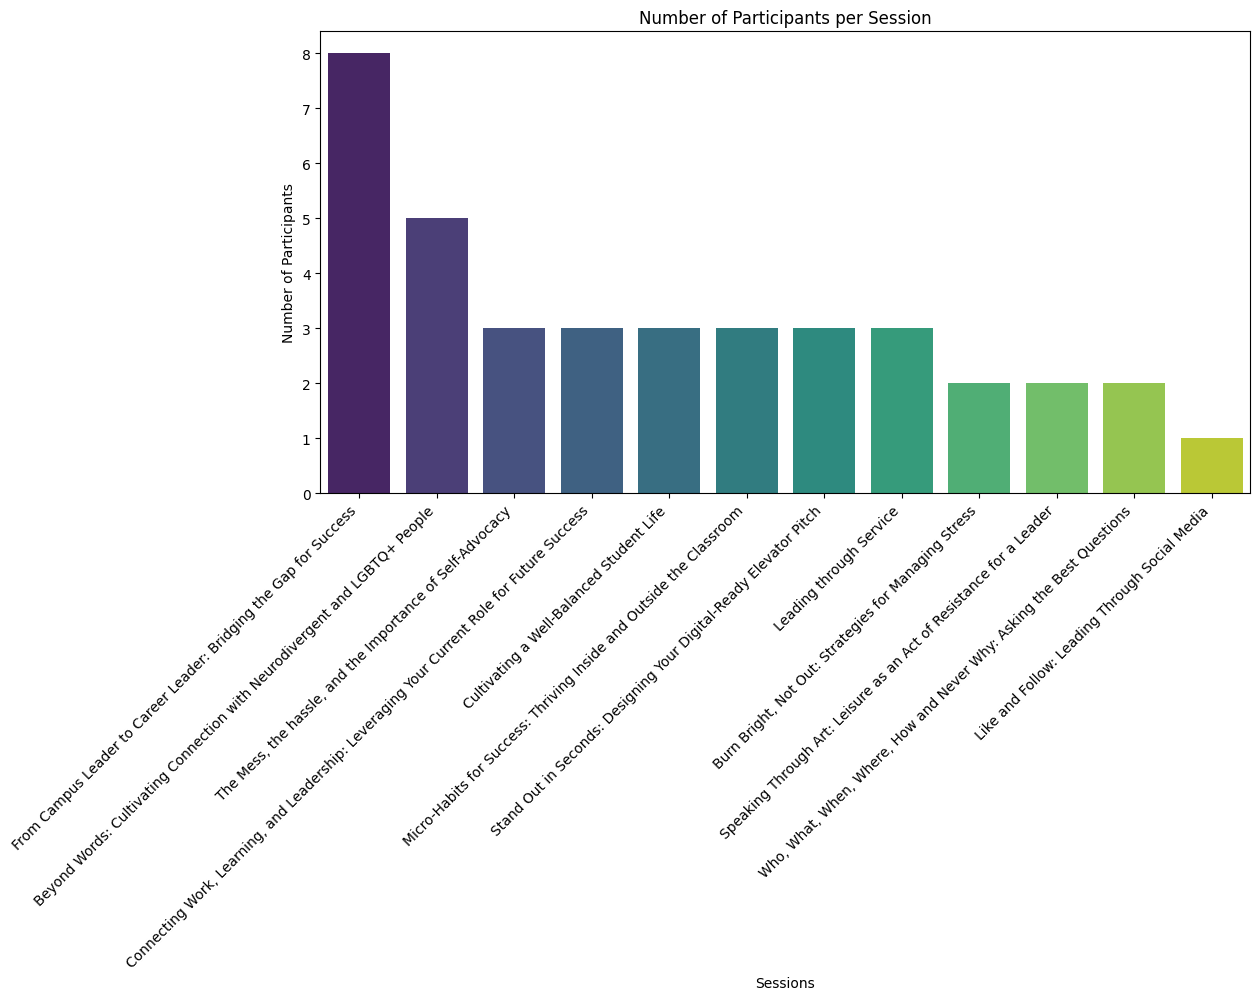

In [ ]:
# Step 1: Count attendance per session
session_counts = df["Which Session did you attend?"].value_counts()

# Step 2: Plot Bar Chart for session attendance
plt.figure(figsize=(12, 6))
sns.barplot(x=session_counts.index, y=session_counts.values, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Sessions")
plt.ylabel("Number of Participants")
plt.title("Number of Participants per Session")
plt.show()


In [ ]:
likert_cols = [
    '"As a result of attending this session, I have gained a better understanding of my strengths and areas for development in my career journey."',
    '"As a result of attending this session, I feel more confident in my ability to inspire, motivate, and lead others effectively."',
    '"This session has improved my ability to clearly and effectively communicate with others in a professional setting."',
    '"This session has deepened my understanding of equity, inclusion, and how to engage in inclusive practices."',
    '"I feel more confident in leveraging technology to complete tasks, enhance my work efficiency, or achieve my goals as a result of this program."'
]


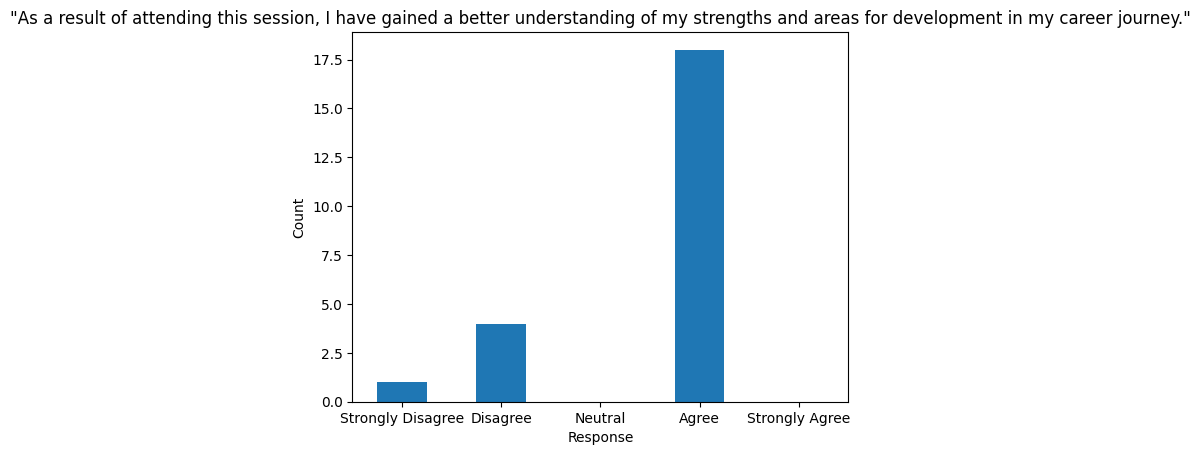

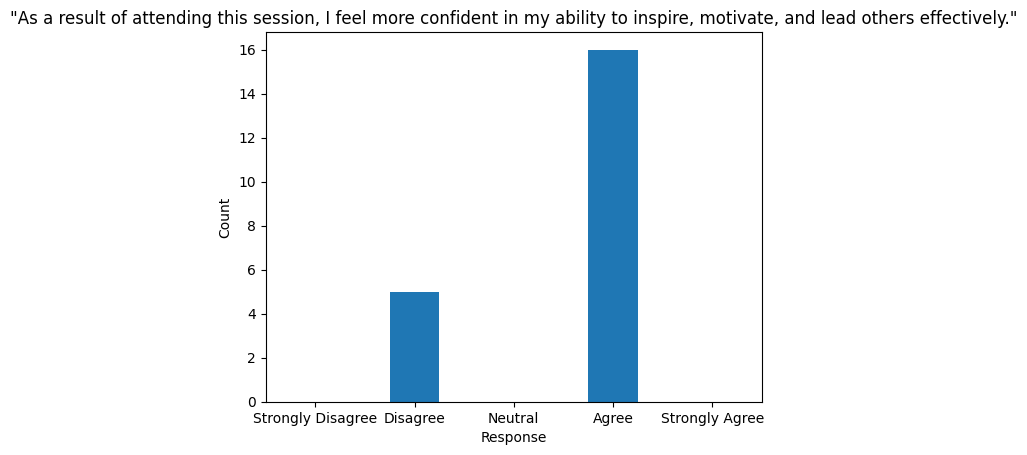

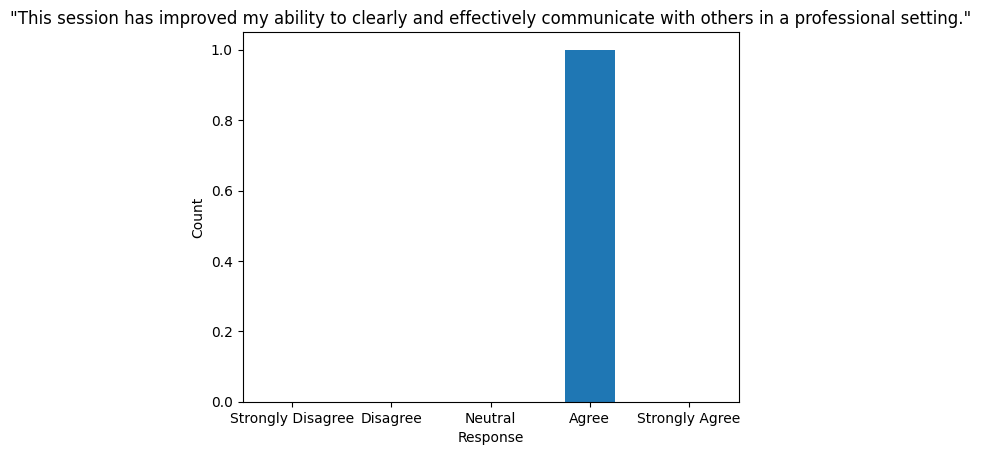

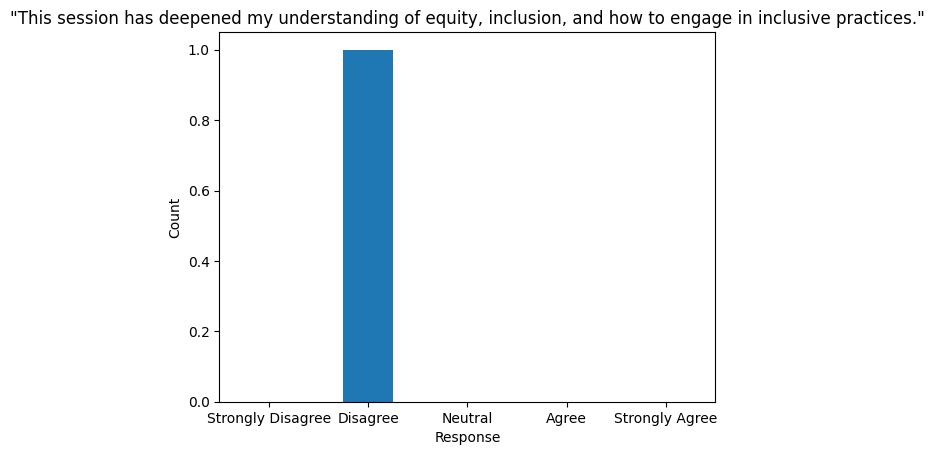

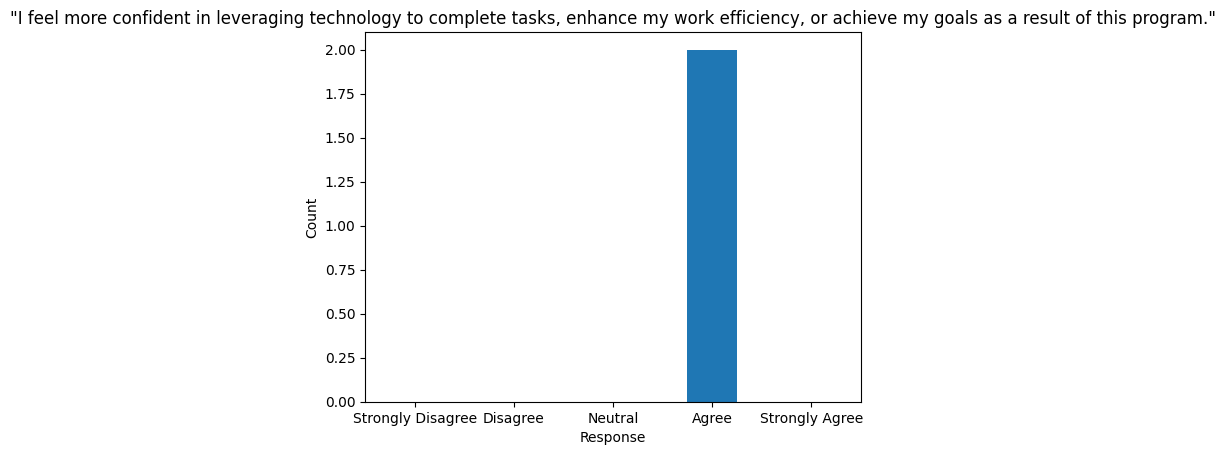

In [ ]:
import matplotlib.pyplot as plt

for col in likert_cols:
    df[col].value_counts().reindex([
        'Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree'
    ]).plot(kind='bar', title=col, rot=0)
    plt.xlabel('Response')
    plt.ylabel('Count')
    plt.show()


<ipython-input-71-fb57430a9609>:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


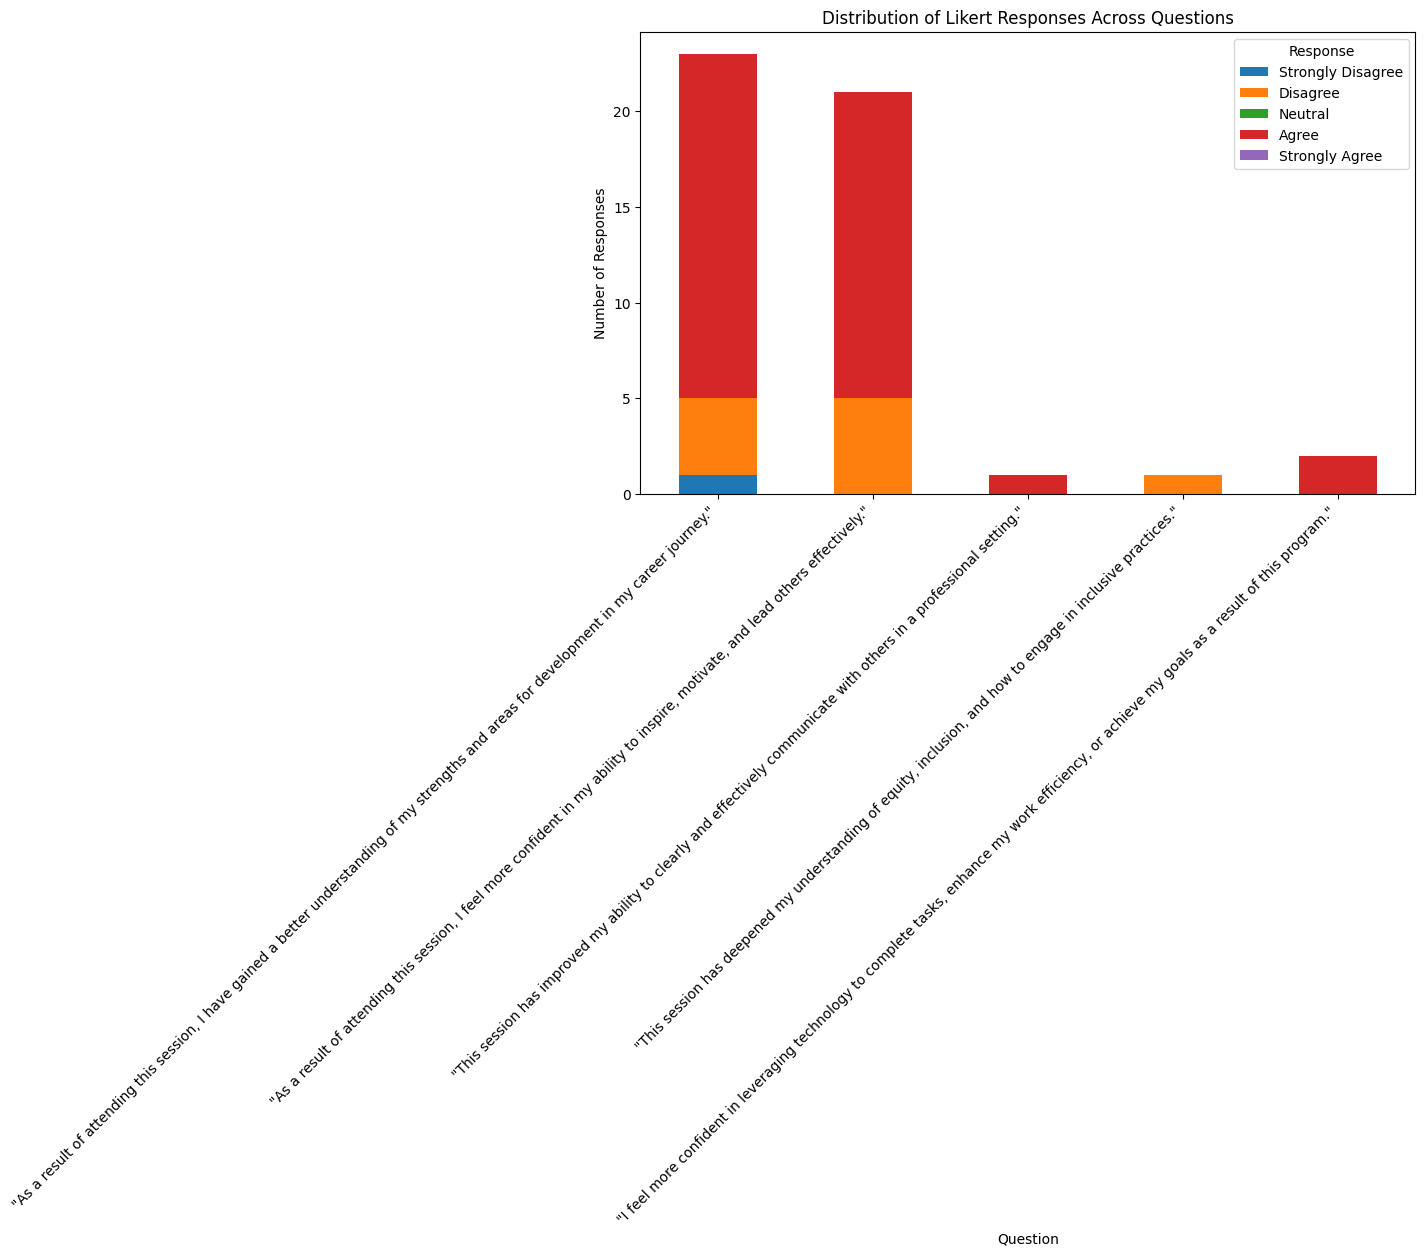

In [ ]:
import pandas as pd

# Clean and reorder Likert responses
likert_order = ['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree']

# Count responses for each column
likert_summary = pd.DataFrame()
for col in likert_cols:
    counts = df[col].value_counts().reindex(likert_order, fill_value=0)
    likert_summary[col] = counts

# Transpose for plotting
likert_summary = likert_summary.T

# Plot stacked bar chart
likert_summary.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Distribution of Likert Responses Across Questions')
plt.ylabel('Number of Responses')
plt.xlabel('Question')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Response')
plt.tight_layout()
plt.show()


<ipython-input-72-4491d93de08c>:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


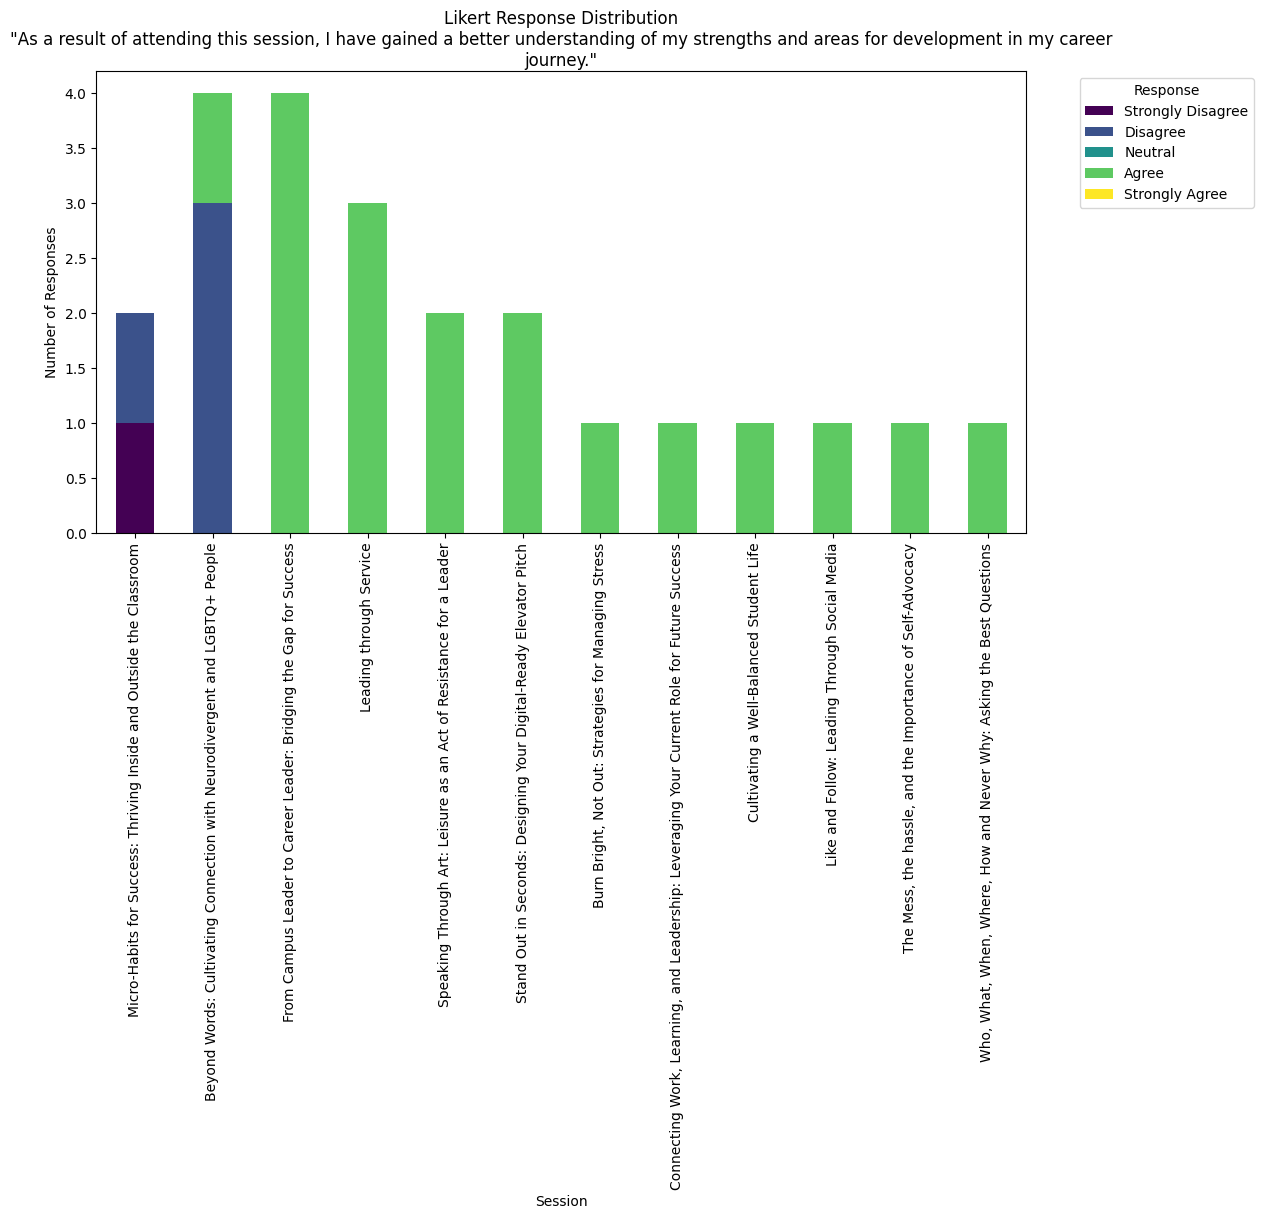

<ipython-input-72-4491d93de08c>:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


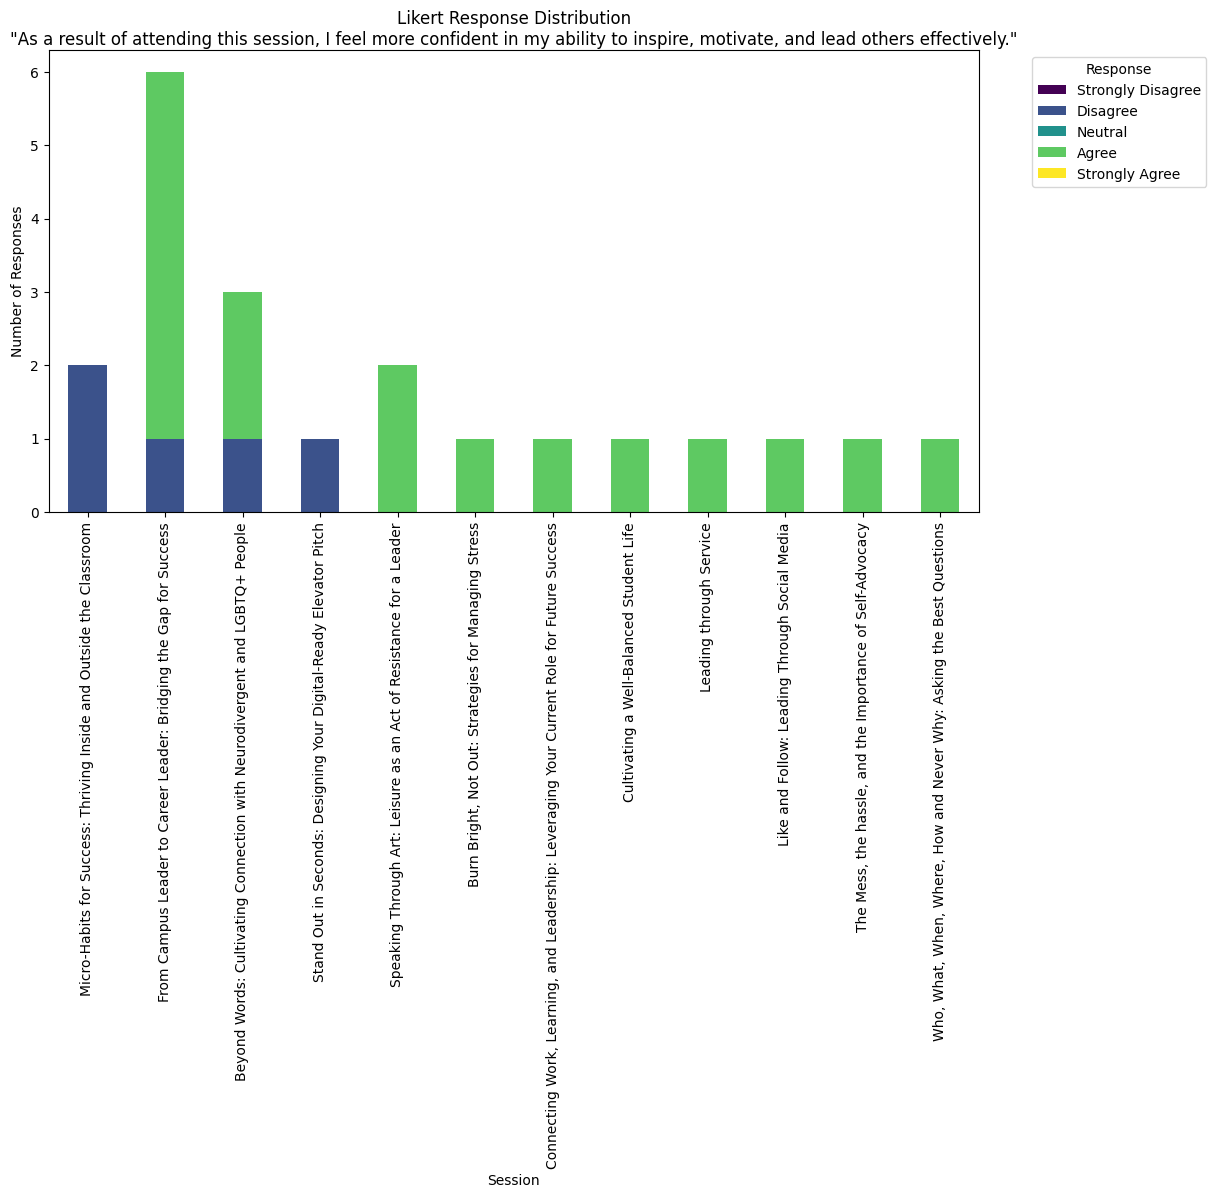

<ipython-input-72-4491d93de08c>:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


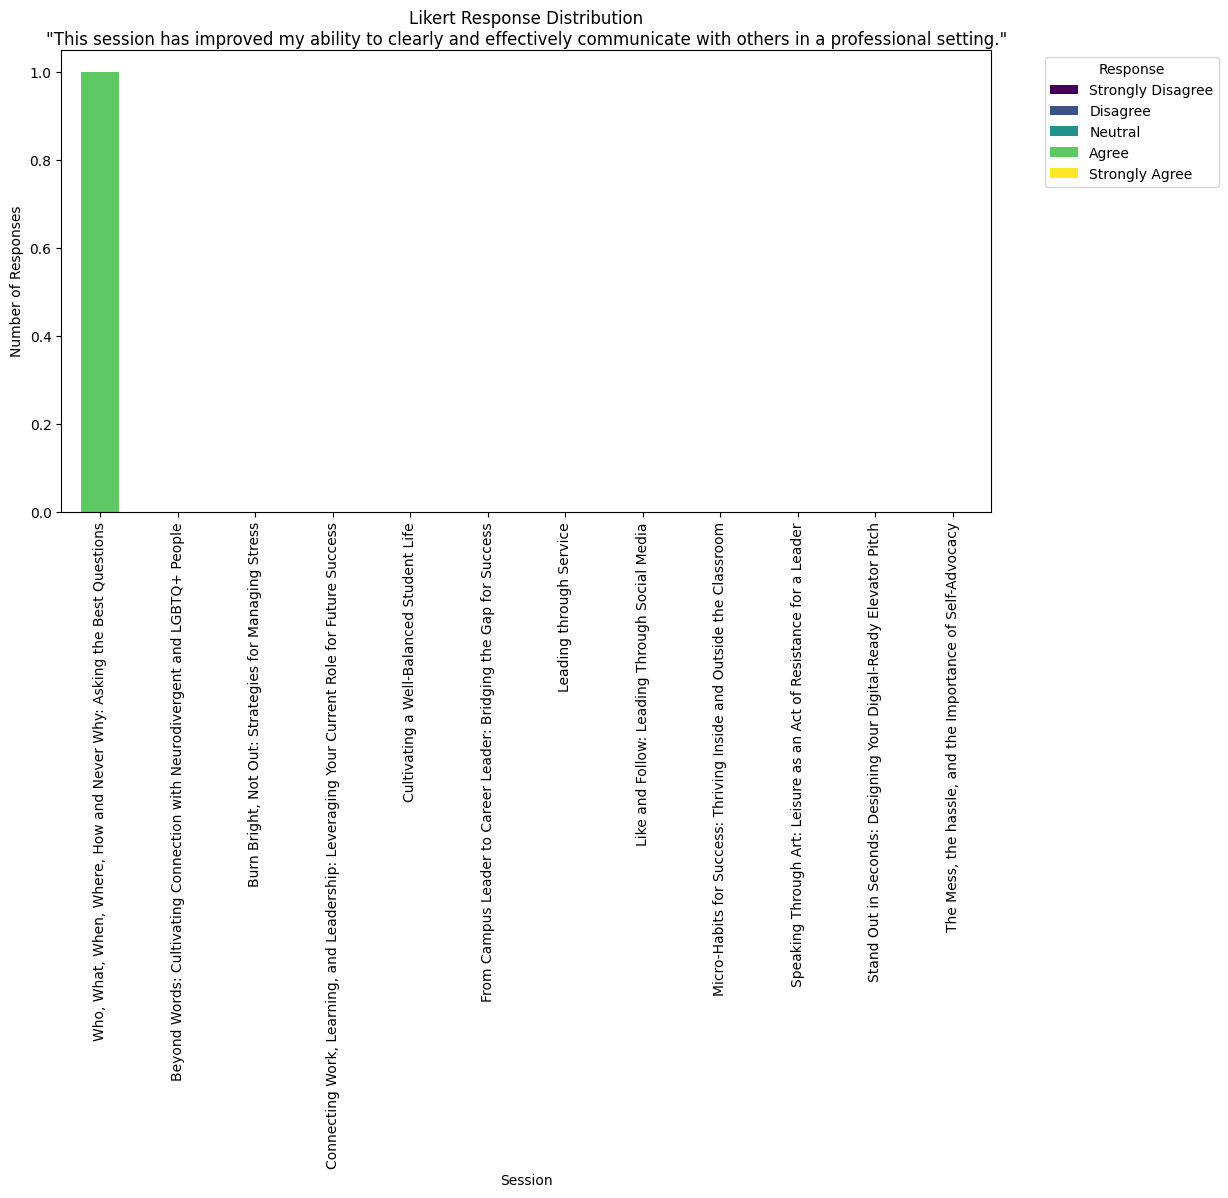

<ipython-input-72-4491d93de08c>:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


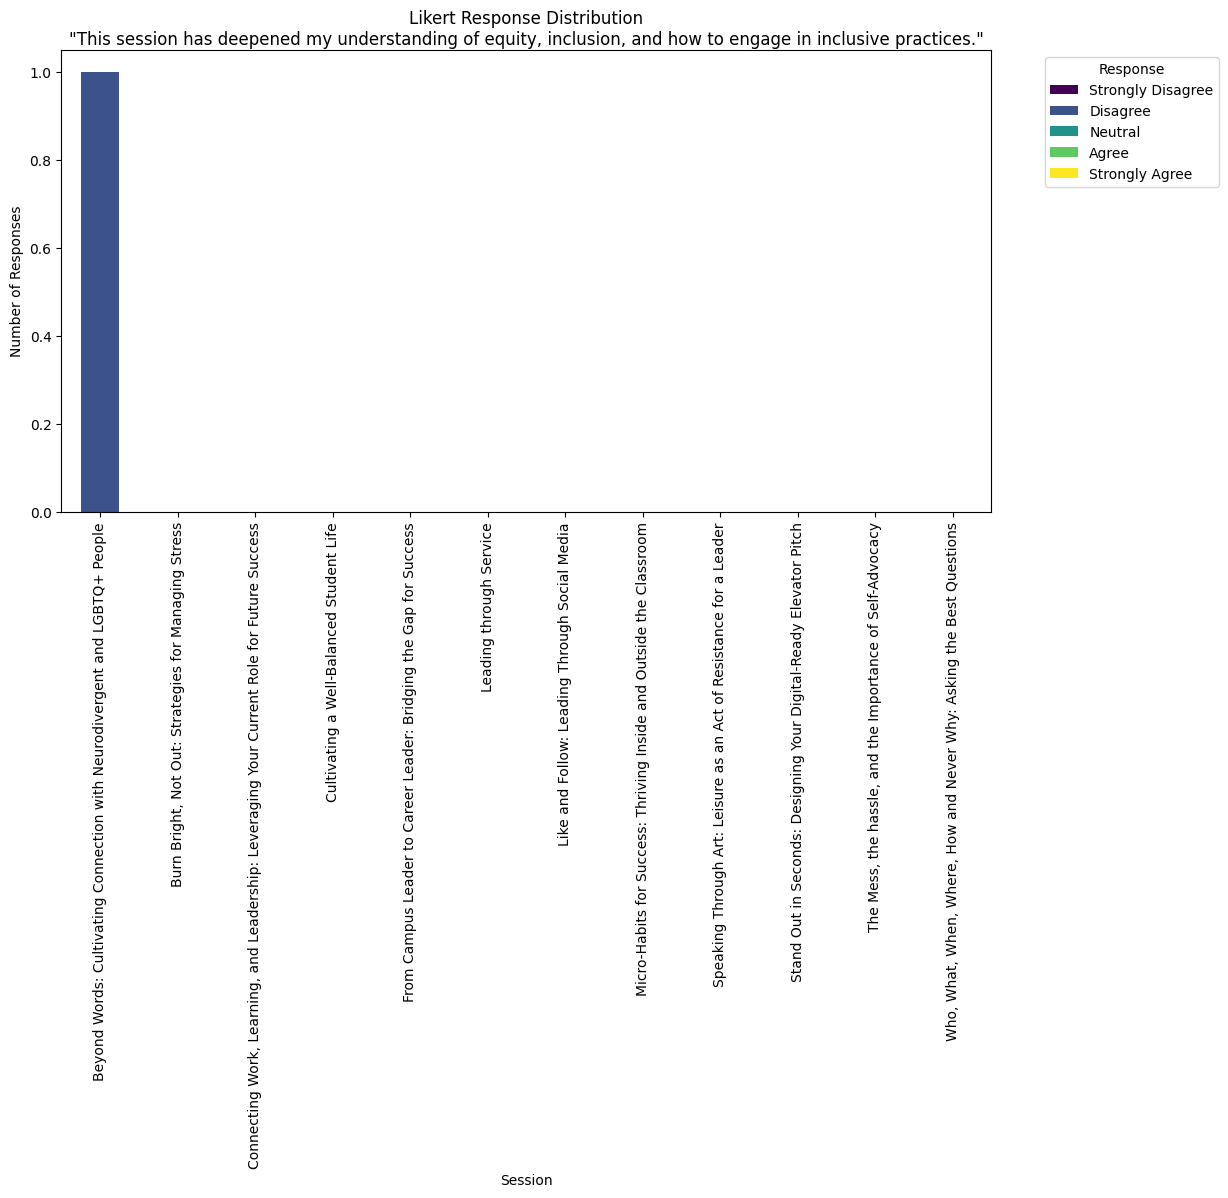

<ipython-input-72-4491d93de08c>:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


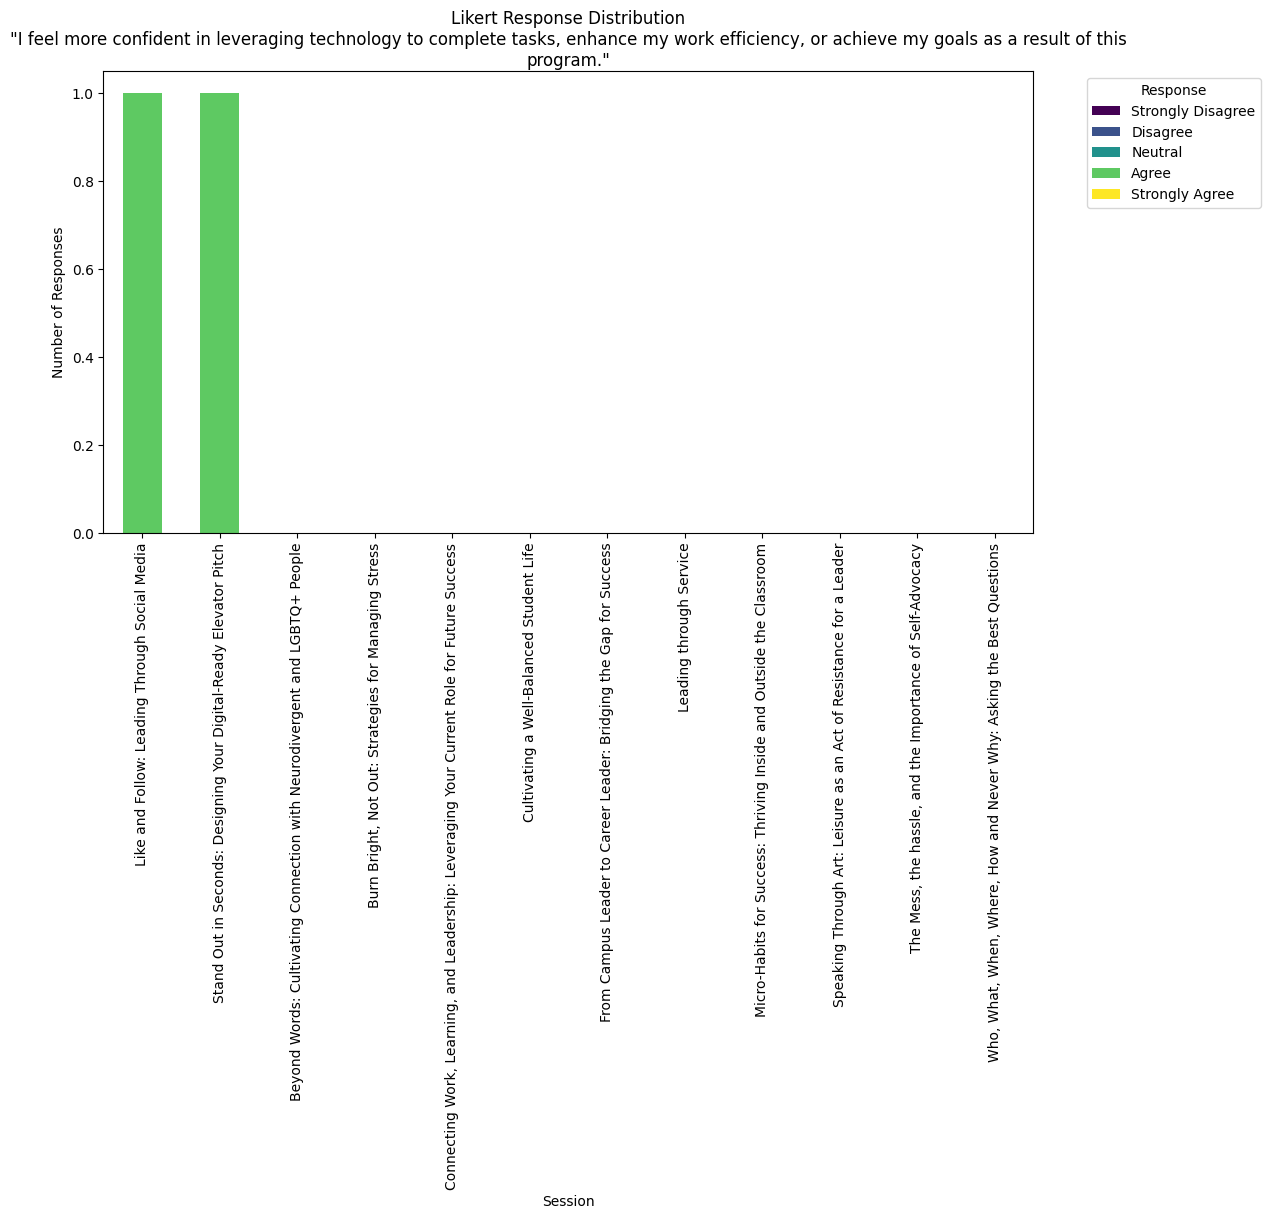

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Define Likert response order and the relevant columns
likert_order = ['Strongly Disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly Agree']

likert_cols = [
    '"As a result of attending this session, I have gained a better understanding of my strengths and areas for development in my career journey."',
    '"As a result of attending this session, I feel more confident in my ability to inspire, motivate, and lead others effectively."',
    '"This session has improved my ability to clearly and effectively communicate with others in a professional setting."',
    '"This session has deepened my understanding of equity, inclusion, and how to engage in inclusive practices."',
    '"I feel more confident in leveraging technology to complete tasks, enhance my work efficiency, or achieve my goals as a result of this program."'
]

# Loop through each Likert question
for col in likert_cols:
    # Group by session and count response values
    grouped = df.groupby("Which Session did you attend?")[col].value_counts().unstack().reindex(columns=likert_order, fill_value=0)

    # Sort sessions by total response count (row sum)
    grouped = grouped.sort_values(by=grouped.columns.tolist(), ascending=False)

    # Plot stacked bar chart
    grouped.plot(kind='bar', stacked=True, figsize=(12,6), colormap='viridis')
    plt.title(f'Likert Response Distribution\n{col}', wrap=True)
    plt.ylabel('Number of Responses')
    plt.xlabel('Session')
    plt.xticks(rotation=90)
    plt.legend(title='Response', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

